# Building a GPT Model from Scratch

This notebook implements the **GPT-2 (124M) architecture** from the ground up in PyTorch and
then trains it. It is a decoder-only Transformer, and every component is defined **exactly
once**, in the order it is used:

1. Configuration
2. Imports and tokenization
3. Layer Normalization
4. GELU activation
5. Feed-Forward network
6. Multi-head causal self-attention
7. Transformer block (assembling 3-6 with residual connections)
8. The full GPT model
9. Inspecting the model (parameter count and size)
10. Autoregressive text generation
11. Cross-entropy loss
12. Perplexity
13. The training corpus
14. Batching: Dataset and DataLoader
15. Loss over a data loader
16. The training loop
17. Decoding strategies: temperature and top-k
18. Saving and loading weights

## The whole flow

**Build the architecture (1-9).** Text becomes token IDs through GPT-2's byte-pair encoder.
Each ID indexes a learned token embedding; a learned positional embedding for that slot is
added to it, producing the vector that enters the network. That vector passes through twelve
identical Transformer blocks. Inside each block, attention lets every token read from the
tokens before it - never after, which the causal mask enforces - and a position-wise
feed-forward network then transforms each token independently. Both sub-layers are wrapped in
residual connections and preceded by LayerNorm. After the last block, a final LayerNorm and a
linear projection turn each position's vector into 50257 logits, one score per vocabulary
entry.

**Check it runs (10).** With random weights, generate text greedily: take the logits at the
last position, pick the highest-scoring token, append it, repeat. The output is meaningless,
which is expected - what it proves is that every shape, mask, and index in the pipeline is
correct.

**Define what "wrong" means (11-12).** The target at each position is simply the next token in
the text, so the corpus supervises itself. Cross-entropy measures the negative average
log-probability the model assigned to those correct tokens; perplexity is its exponential.
An untrained model scores `ln(50257) = 10.82`, the baseline every run is measured against.

**Feed it data (13-15).** One short story is tokenized, sliced by a sliding window into
fixed-length chunks paired with the same chunk shifted one position, split 90/10 into training
and validation sets, and served in batches.

**Train it (16).** For each batch: clear gradients, compute the loss, back-propagate, step
AdamW. Every few steps, measure both losses; after each epoch, print a sample so progress is
visible as text rather than only as a number.

**Control the output (17-18).** Greedy decoding is replaced by temperature scaling and top-k
sampling, both acting on the logits before the softmax. The trained weights are then saved and
reloaded.

## How this differs from real GPT-2

The architecture here is GPT-2's. What differs is scale, one parameter-saving trick, and the
training-run engineering that a short CPU run does not need.

| | This notebook | GPT-2 (124M) |
|---|---|---|
| Layers / heads / width | 12 / 12 / 768 | identical |
| Tokenizer | tiktoken GPT-2 BPE, 50257 | identical |
| Attention, LayerNorm, GELU, pre-LN | identical | identical |
| `context_length` | 256 | 1024 |
| Output head | its own matrix (162.4M params) | tied to the token embedding (124M) |
| `qkv_bias` | `False` | `True` in the published checkpoints |
| Training data | 1 short story, 5145 tokens | WebText, roughly 40GB |
| Training compute | 90 optimizer steps, minutes on a CPU | weeks on many GPUs |
| LR schedule, gradient clipping | none | warmup, cosine decay, clipping |
| Generation | full forward pass every step | KV cache |
| Result | memorizes the corpus | generalizes |

The consequence worth stating plainly: **the model trained here is a memorizer, not a language
model.** With 4608 training tokens against 162M parameters, the training loss falls to 0.391
while the validation loss rises after epoch 7, and the samples in section 16 turn into
verbatim passages from the story. That is not a bug in the code - the same code at GPT-2's
data scale is GPT-2 - it is what a 20KB corpus buys. Section 16 shows the divergence in the
loss curves rather than hiding it.

Also absent, because they come after pretraining rather than inside it: supervised
fine-tuning, instruction tuning, and RLHF. None of them change the architecture below; they
change what it is trained on.

**How to read it.** Each section states what the component does, then the design decisions
behind it: what was chosen, what the alternative was, and what changes if you pick the other
one. The code is written for readability over speed, so where a faster-but-denser formulation
exists it is named in the text rather than used. No pretrained checkpoint is loaded anywhere -
every weight in this notebook is learned here.


![images/full-pipeline.png](images/full-pipeline.png)

## 1. Model Configuration

All architectural hyper-parameters live in one dictionary. These values reproduce the
smallest GPT-2 model, commonly labelled 124M.

**Design decisions**

- **A dict rather than a dataclass or individual arguments.** Every submodule receives the
  whole `cfg` object, so adding a hyper-parameter later does not mean editing constructor
  signatures down the chain. The cost is no type checking and no editor autocompletion on
  the keys - a typo like `cfg["emb_dm"]` fails at runtime, not at import.
- **`vocab_size = 50257`** is not arbitrary: 50000 learned BPE merges + 256 single-byte base
  tokens + 1 `<|endoftext|>` token. It must match the tokenizer exactly, since the output
  head produces one logit per entry.
- **`context_length = 256`** fixes the size of the learned positional embedding table. The
  model cannot process a sequence longer than this, and unlike relative schemes (RoPE,
  ALiBi) it cannot extrapolate past it - positions beyond 255 simply have no embedding.
  GPT-2 used 1024; it is shortened here because attention cost grows with the square of
  sequence length, and 256 keeps the training run in section 16 to minutes on a CPU. The
  only structural consequence is a smaller positional table, so the parameter count comes
  out about 0.6M below the real 124M.
- **`qkv_bias = False`.** The original OpenAI GPT-2 weights do carry biases on the Q/K/V
  projections. The flag exists so the same class can load those checkpoints; left off here
  because we train from scratch and the biases are redundant next to LayerNorm's shift.
- **`drop_rate = 0.1`** matches GPT-2's training setup. Modern reimplementations trained for
  a single pass over a very large corpus often set this to 0.0, since there is little to
  overfit to.


In [4]:
# GPT-2 "small" (124M parameters) configuration
GPT_CONFIG_124M = {
    "vocab_size":     50257,   # number of tokens in the GPT-2 BPE vocabulary
    "context_length": 256,     # maximum sequence length (GPT-2 used 1024; shortened to train on CPU)
    "emb_dim":        768,     # embedding / hidden dimension
    "n_heads":        12,      # number of attention heads
    "n_layers":       12,      # number of stacked Transformer blocks
    "drop_rate":      0.1,     # dropout probability
    "qkv_bias":       False,   # whether Q/K/V linear layers use a bias term
}

## 2. Imports and Tokenization

PyTorch for the model, OpenAI's `tiktoken` for GPT-2 byte-pair encoding (BPE). Two short
sentences are tokenized and stacked into one batch tensor of shape
`(batch_size, num_tokens)`, which is the input format the model expects.

**Design decisions**

- **BPE rather than word-level or character-level tokenization.** Word-level needs an
  out-of-vocabulary token for anything unseen; character-level makes sequences several times
  longer, and attention cost grows with the square of sequence length. BPE keeps common words
  as single tokens while still being able to spell out any string from byte-level pieces, so
  nothing is ever unrepresentable.
- **Using the pretrained `gpt2` encoding instead of training our own merges.** The vocabulary
  has to match `vocab_size` in the config, and reusing OpenAI's keeps this notebook
  compatible with their released weights.
- **Both sentences here happen to be 4 tokens long**, so `torch.stack` works directly. Mixed
  lengths would need padding plus an attention mask; that is skipped deliberately to keep the
  masking logic in section 6 purely causal.


In [5]:
import torch
import torch.nn as nn
import tiktoken

# Reproducibility
torch.manual_seed(123)

# GPT-2 uses byte-pair encoding (BPE)
tokenizer = tiktoken.get_encoding("gpt2")

# Encode a couple of sentences and stack them into one batch tensor.
batch = torch.stack([
    torch.tensor(tokenizer.encode("Every effort moves you")),
    torch.tensor(tokenizer.encode("Every day holds a")),
], dim=0)

print("Batch shape:", batch.shape)   # (2 sentences, 4 tokens each)
print(batch)

Batch shape: torch.Size([2, 4])
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


## 3. Layer Normalization

`LayerNorm` normalizes activations across the **embedding dimension**, so each token vector
ends up with zero mean and unit variance. Two learnable parameters, `scale` (gamma) and
`shift` (beta), let the network scale and offset that result, which means it can partially
undo the normalization where that helps.

**Design decisions**

- **Normalizing across the embedding dimension, not the batch.** Each token is normalized
  using only its own 768 values. Nothing depends on batch size or on the other sequences in
  the batch, so the operation behaves identically during training, single-example inference,
  and token-by-token generation. BatchNorm normalizes across the batch and therefore needs
  running statistics and behaves differently in eval mode - a poor fit for variable-length
  autoregressive decoding.
- **Writing it out instead of calling `nn.LayerNorm`.** The two are numerically equivalent;
  `nn.LayerNorm` is faster because it is a fused kernel. The explicit version is here so the
  mean/variance/rescale steps are visible.
- **`unbiased=False`** divides the variance by N rather than N-1. This matches the reference
  GPT-2 implementation. With 768 elements the numerical difference is negligible, but the
  choice must match if you intend to load pretrained weights.
- **`eps = 1e-5` added inside the square root**, not after it, so the denominator can never be
  zero for a constant-valued token vector.


In [6]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))   # learnable gain  (gamma)
        self.shift = nn.Parameter(torch.zeros(emb_dim))  # learnable bias  (beta)

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [7]:
# Quick sanity check: after LayerNorm each row has ~0 mean and ~1 variance.
example = torch.randn(2, 5)
ln_out = LayerNorm(emb_dim=5)(example)
print("Mean:", ln_out.mean(dim=-1).detach())
print("Var :", ln_out.var(dim=-1, unbiased=False).detach())

Mean: tensor([-2.9802e-08,  0.0000e+00])
Var : tensor([1.0000, 1.0000])


## 4. GELU Activation

GPT-2 uses the **Gaussian Error Linear Unit** rather than ReLU. GELU is smooth everywhere and
lets small negative inputs through with a small negative output, instead of clamping all of
them to exactly zero.

**Design decisions**

- **GELU over ReLU.** ReLU has zero gradient for every negative input, so a unit that gets
  pushed negative receives no gradient signal and can stop updating. GELU's gradient is
  nonzero on both sides of the origin, which removes that failure mode and empirically
  trains deep Transformer stacks better.
- **The `tanh` approximation rather than the exact `erf` form.** The exact definition uses the
  Gaussian CDF; this polynomial-plus-`tanh` version is what the original GPT-2 shipped with,
  and reproducing it keeps activations bit-comparable with the reference implementation. In
  PyTorch the same thing is available as `nn.GELU(approximate="tanh")`.
- **Implemented as an `nn.Module` with no parameters.** It could be a plain function; the
  module form lets it drop straight into the `nn.Sequential` in the next section.


In [8]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # tanh-based approximation of GELU (as used in the original GPT-2)
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

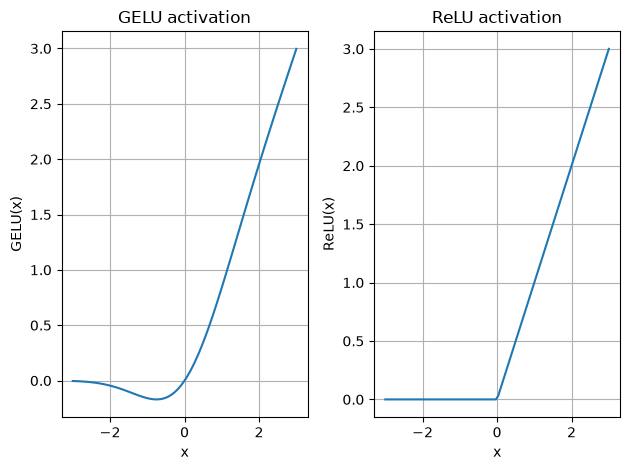

In [9]:
# Visualize GELU vs. ReLU to see the smooth, non-zero-for-negatives behaviour.
import matplotlib.pyplot as plt

x = torch.linspace(-3, 3, 100)
for i, (fn, label) in enumerate([(GELU(), "GELU"), (nn.ReLU(), "ReLU")], start=1):
    plt.subplot(1, 2, i)
    plt.plot(x, fn(x))
    plt.title(f"{label} activation")
    plt.xlabel("x"); plt.ylabel(f"{label}(x)"); plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Feed-Forward Network

Each Transformer block contains a position-wise feed-forward network. It expands the
embedding dimension by 4x, applies GELU, then contracts back to the original width.

**Design decisions**

- **Position-wise: the same weights applied to every token independently.** No information
  moves between positions here. All cross-token mixing happens in attention, so the two
  sub-layers have cleanly separated jobs - attention decides *what to look at*, the FFN
  decides *what to compute* with what it found.
- **The 4x expansion factor.** This is GPT-2's convention and it is where most of the model's
  parameters live: 2 x 768 x 3072 per block, versus 4 x 768 x 768 for attention. Widening
  before the nonlinearity gives GELU a higher-dimensional space to carve up; contracting
  afterwards keeps the residual stream at a fixed 768 so blocks remain stackable.
- **Two linear layers rather than more.** Depth in this architecture comes from stacking
  blocks, not from deepening the FFN.
- **Biases left on** (`nn.Linear` defaults to `bias=True`), matching GPT-2.


In [10]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),   # expand  (768 -> 3072)
            GELU(),                                          # activation
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),   # contract (3072 -> 768)
        )

    def forward(self, x):
        return self.layers(x)

In [11]:
# The FFN preserves shape: (batch, tokens, emb_dim) in -> same shape out.
ff_out = FeedForward(GPT_CONFIG_124M)(torch.rand(2, 3, 768))
print("FeedForward output shape:", ff_out.shape)

FeedForward output shape: torch.Size([2, 3, 768])


## 6. Multi-Head Causal Self-Attention

This is where tokens exchange information. Each token emits a **query** describing what it is
looking for, a **key** describing what it offers, and a **value** carrying the content it
contributes. Every query is scored against every key, the scores are turned into weights with
a softmax, and each token's output is the weighted sum of values.

**Design decisions**

- **Multiple heads instead of one wide attention.** `d_out` is split into `num_heads`
  independent slices of `head_dim = d_out / num_heads`, each with its own attention pattern,
  and the results are concatenated. One head can only produce a single weighted average per
  token; twelve can attend to twelve different things at once. Splitting rather than adding
  heads keeps the parameter count identical to single-head attention.
- **Three separate `Linear` layers for Q, K, V.** A single fused `Linear(d_in, 3 * d_out)`
  followed by a split is one matmul instead of three and is what performance-focused
  implementations use. Three layers are kept here because the naming makes the roles obvious.
- **A causal mask, applied by setting future scores to `-inf` before the softmax.** After the
  softmax those entries become exactly 0, so position *i* can attend only to positions
  <= *i*. Without this, predicting token *i+1* would have access to token *i+1* itself and
  the training objective would be trivially satisfiable.
- **The mask is a registered buffer, not a parameter or a local variable.** As a buffer it
  moves with `.to(device)` and is saved in `state_dict`, but receives no gradient. It is
  allocated once at full `context_length` and sliced to `[:num_tokens, :num_tokens]` per
  call, which avoids rebuilding a triangular matrix on every forward pass.
- **Scores divided by `sqrt(head_dim)` before the softmax.** The dot product of two
  `head_dim`-length vectors has variance proportional to `head_dim`, so without scaling the
  scores grow with head width, the softmax saturates toward one-hot, and its gradient
  vanishes. Dividing keeps the score variance near 1 regardless of head size.
- **Dropout applied to the attention weights, after the softmax.** This means the surviving
  weights no longer sum to 1 during training. That is intentional and is what GPT-2 does; it
  forces each token to not depend on any single source position.
- **A final `out_proj` after merging heads.** Concatenation alone leaves each head's output
  confined to its own slice of the 768 dimensions. The output projection is what lets heads
  combine.

![images/mha.png](images/mha.png)


In [12]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads   # dimension handled by each head

        # Separate learnable projections for queries, keys, and values.
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.out_proj = nn.Linear(d_out, d_out)   # combines the heads back together
        self.dropout = nn.Dropout(dropout)

        # Causal mask (upper triangular, excluding the diagonal). Registered as a
        # buffer so it moves with the model to GPU/CPU but is not a trained parameter.
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        # 1) Project inputs to Q, K, V  ->  (b, num_tokens, d_out)
        keys    = self.W_key(x)
        queries = self.W_query(x)
        values  = self.W_value(x)

        # 2) Split into heads: (b, num_tokens, num_heads, head_dim)
        keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values  = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # 3) Move the head dimension forward: (b, num_heads, num_tokens, head_dim)
        keys    = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values  = values.transpose(1, 2)

        # 4) Scaled dot-product attention scores for every head.
        attn_scores = queries @ keys.transpose(2, 3)

        # 5) Apply the causal mask (block attention to future tokens).
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        # 6) Scale by sqrt(head_dim), softmax over the last dim, then dropout.
        attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # 7) Weighted sum of values, then merge heads back to (b, num_tokens, d_out).
        context_vec = (attn_weights @ values).transpose(1, 2)
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)

        # 8) Final output projection.
        return self.out_proj(context_vec)

## 7. The Transformer Block

A block wires the attention and feed-forward sub-layers together using **pre-LayerNorm**
placement and **residual connections**:

```
x -> LayerNorm -> Attention   -> Dropout -> (+ x)  ->  h
h -> LayerNorm -> FeedForward -> Dropout -> (+ h)  ->  out
```

**Design decisions**

- **Pre-LN rather than post-LN.** The 2017 Transformer normalized *after* the residual
  addition. Pre-LN normalizes the input to each sub-layer instead, leaving an unbroken
  identity path from the first block's input to the last block's output. Gradients travel
  that path without passing through any normalization, which is what makes a 12-block (or
  96-block) stack trainable without a carefully tuned learning-rate warmup. The cost is that
  the final block's output is never normalized, which is why section 8 adds `final_norm`.
- **Residual connections at all.** Each sub-layer computes a *change* to be added to the
  running representation rather than replacing it. A block that has learned nothing useful
  contributes approximately zero, so adding depth cannot make the model worse by
  construction.
- **Dropout on the sub-layer output, before the addition.** The residual path itself is never
  dropped, so the identity route always stays intact.
- **One `drop_shortcut` module reused for both sub-layers.** Dropout holds no state between
  calls - it samples a fresh mask each time - so sharing the module is safe and equivalent to
  having two.
- **The residual stream keeps a constant width of `emb_dim` throughout.** That is what allows
  `n_layers` identical blocks to be stacked with no shape adapters between them.

![images/transformer.png](images/transformer.png)


In [13]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # --- Attention sub-layer (with residual connection) ---
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        # --- Feed-forward sub-layer (with residual connection) ---
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x

In [14]:
# A single block preserves the input shape (batch, tokens, emb_dim).
block_out = TransformerBlock(GPT_CONFIG_124M)(torch.rand(2, 4, 768))
print("TransformerBlock output shape:", block_out.shape)

TransformerBlock output shape: torch.Size([2, 4, 768])


## 8. The Full GPT Model

Assembling the complete model:

1. **Token embeddings** map token IDs to vectors.
2. **Positional embeddings** add information about each token's position.
3. A stack of `n_layers` **Transformer blocks** processes the sequence.
4. A **final LayerNorm** normalizes the output of the last block.
5. A linear **output head** projects each position to vocabulary-sized logits.

**Design decisions**

- **Positional embeddings are learned, not sinusoidal.** GPT-2 trains a
  `(context_length, emb_dim)` lookup table from scratch. Sinusoidal encodings are
  parameter-free and extrapolate to unseen lengths; learned ones fit the data better within
  the trained range but stop dead at `context_length`. Modern models mostly use neither and
  apply rotary embeddings inside attention instead.
- **Position is added to the token embedding, not concatenated.** Concatenation would need
  extra dimensions and widen every downstream layer. Addition keeps the residual stream at
  768 and lets the model allocate whatever subspace it wants to positional information.
- **Both embeddings are looked up, then dropout is applied once to their sum**, rather than to
  each separately.
- **`final_norm` before the output head.** This is required by the pre-LN choice in section 7:
  the last block's residual output has not passed through a normalization, and feeding an
  unnormalized, potentially large-magnitude vector straight into the vocabulary projection
  destabilizes training.
- **The blocks are held in `nn.Sequential`.** That works only because a block takes one tensor
  and returns one tensor. The moment a block needs a second argument - an attention mask, or a
  KV cache during generation - this has to become an `nn.ModuleList` with an explicit loop.
- **The output head is a separate matrix, not tied to the token embedding.** Real GPT-2 ties
  them - one `(vocab_size, emb_dim)` matrix used both to look up token vectors and to produce
  logits - which is where its 124M figure comes from. Section 9 works through what that saves
  and what it costs. It is left untied here because tying forces a much smaller weight
  initialization, and that visibly slows the short training run in section 16.
- **Weight initialization is left at PyTorch's defaults.** `nn.Linear` gets Kaiming-uniform
  values, which land near `std = 0.02` at these widths - close to GPT-2's own scheme. The
  interesting default is `nn.Embedding`, which is `normal(0, 1)`: token vectors start large
  relative to everything the blocks add, so token identity stays legible in the residual
  stream from the first step, and the model fits a small corpus quickly. That default is only
  safe because the output head is separate; see section 9.
- **`out_head` has `bias=False`.** A per-vocabulary-entry bias would act as a learned prior on
  token frequency; GPT-2 omits it, and the softmax is shift-invariant so a single global bias
  would do nothing anyway.

![images/full-pipeline.png](images/full-pipeline.png)


In [15]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Stack of Transformer blocks.
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        # Output projection to vocabulary logits (no bias, as in GPT-2).
        # Its own matrix, not tied to tok_emb - see section 9 for what tying would change.
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape

        tok_embeds = self.tok_emb(in_idx)
        # Position ids [0, 1, ..., seq_len-1] on the same device as the input.
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))

        x = tok_embeds + pos_embeds     # combine token + positional information
        x = self.drop_emb(x)
        x = self.trf_blocks(x)          # the bulk of the computation
        x = self.final_norm(x)
        logits = self.out_head(x)       # (batch, seq_len, vocab_size)
        return logits

In [16]:
# Instantiate the model and run our tokenized batch through it.
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

logits = model(batch)
print("Input batch shape :", batch.shape)
print("Output logits shape:", logits.shape)   # (2, 4, 50257)

Input batch shape : torch.Size([2, 4])
Output logits shape: torch.Size([2, 4, 50257])


## 9. Inspecting the Model

Confirming the parameter count and estimating the memory footprint.

The count below is about 162.4M, not the 124M in this notebook's title. The difference is
**weight tying**, which real GPT-2 uses and this implementation does not.

**What tying is.** The token embedding maps token IDs to 768-dim vectors; the output head maps
768-dim vectors back to scores over token IDs. Both are `(vocab_size, emb_dim)` matrices
describing the same relationship in opposite directions. GPT-2 stores one matrix and uses it
for both, writing `self.out_head.weight = self.tok_emb.weight` - an assignment, not a copy, so
the two attributes point at one tensor and gradients from either use accumulate into it. That
matrix is 50257 x 768, about 38.6M parameters, which is the entire gap between 162.4M and
124M. The 124M label refers to the tied count.

Note also that the positional table here is 256 x 768 rather than GPT-2's 1024 x 768, because
of the shortened `context_length`; that accounts for a further 0.6M. Every other tensor
matches GPT-2 (124M) exactly.

**Design decisions**

- **Untied here, tied in GPT-2.** Tying is not free: the same matrix must simultaneously
  produce useful input vectors and useful output logits. Because it feeds the logits, it has
  to be initialized small - roughly `std = 0.02` - or the logits come out with a standard
  deviation near `sqrt(768) = 28` and the initial cross-entropy lands in the hundreds instead
  of at `ln(50257) = 10.82`. Small embeddings then mean token identity is weak in the residual
  stream relative to what the blocks add, and the short training run in section 16 converges
  far more slowly as a result. Untied, `nn.Embedding` keeps its `normal(0, 1)` default and the
  model fits the corpus within ten epochs. The trade is 38.6M parameters against training
  speed on a small corpus; at GPT-2's scale and step count, tying wins.
- **`nn.Module.parameters()` de-duplicates shared tensors**, so if the two were tied, the total
  below would report the shared matrix once rather than needing a subtraction.
- **The size estimate assumes float32, 4 bytes per parameter, and covers weights only.**
  Training also needs gradients (4 bytes each), Adam's two optimizer states (8 more), and
  stored activations for the backward pass - in practice several times the figure below.


In [17]:
# nn.Module.parameters() yields each tensor once.
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# The output head and the token embedding are two separate matrices here.
print("out_head.weight is tok_emb.weight:", model.out_head.weight is model.tok_emb.weight)

# What the count would be with GPT-2's weight tying: one matrix instead of two.
tied = total_params - model.tok_emb.weight.numel()
print(f"Tied parameter count: {tied:,}")
print(f"Tying would save:     {model.tok_emb.weight.numel():,}")

# Memory footprint, float32 weights only.
total_size_mb = (total_params * 4) / (1024 ** 2)
print(f"Approx. model size: {total_size_mb:.2f} MB")


Total parameters: 162,419,712
out_head.weight is tok_emb.weight: False
Tied parameter count: 123,822,336
Tying would save:     38,597,376
Approx. model size: 619.58 MB


## 10. Generating Text

Generation is **autoregressive**: feed the current sequence to the model, take the logits at
the last position, pick the next token, append it, and repeat with the extended sequence.

**Design decisions**

- **Greedy decoding via `argmax`.** Always taking the highest-scoring token is deterministic
  and makes the output easy to reason about, but it is also why real models sound repetitive
  under it - there is no mechanism to escape a loop once entered. Temperature scaling, top-k,
  and nucleus sampling all slot in at exactly the `probas` line below.
- **The `softmax` before `argmax` is mathematically redundant.** Softmax is monotonic, so
  `argmax(softmax(logits)) == argmax(logits)`. It is kept because it marks the point where the
  distribution exists, which is where any sampling strategy would be inserted.
- **Only the final position's logits are used.** The model emits a prediction for every
  position in the sequence; during generation all but the last are discarded. During training
  every one of them is a supervised target, which is what makes the objective efficient.
- **The context is truncated to the last `context_size` tokens** each step. Once generation
  runs past the window, the earliest tokens fall out - the model has no memory beyond it.
- **No KV cache.** Each step re-runs the full forward pass over the entire sequence, so keys
  and values for tokens already processed are recomputed every time. Caching them is the
  standard optimization and turns per-step cost from quadratic to linear in sequence length;
  it is left out here because it would require threading mutable state through every module.
- **`torch.no_grad()` and `model.eval()`.** The first skips building the autograd graph, which
  is unnecessary during inference and saves memory. The second disables dropout, without which
  generation would be nondeterministic even under greedy decoding.

The model is **untrained**, so the output is meaningless. What it does confirm is that
tokenization, embedding, twelve blocks of attention, masking, and decoding all run end to end
with correct shapes.


![nwp.png](nwp.png)

In [18]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    """Greedy autoregressive generation.

    idx: (batch, n_tokens) tensor of token IDs for the current context.
    """
    for _ in range(max_new_tokens):
        # Keep only the last `context_size` tokens (the model's window).
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)

        # Look only at the prediction for the final position.
        logits = logits[:, -1, :]                       # (batch, vocab_size)
        # Softmax is monotonic so it does not change the argmax; it marks where a
        # sampling strategy (temperature / top-k) would replace the greedy pick.
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # greedy pick

        # Append the predicted token and continue.
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

In [19]:
start_context = "Hello, I am"
encoded = torch.tensor(tokenizer.encode(start_context)).unsqueeze(0)  # add batch dim
print("Encoded input:", encoded.tolist())

model.eval()  # disable dropout for deterministic generation
out = generate_text_simple(
    model=model,
    idx=encoded,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"],
)

print("Generated token IDs:", out.tolist())
print("Decoded text:", tokenizer.decode(out.squeeze(0).tolist()))

Encoded input: [[15496, 11, 314, 716]]
Generated token IDs: [[15496, 11, 314, 716, 13240, 11381, 4307, 7640, 16620, 34991]]
Decoded text: Hello, I am Laur inhab DistrinetalkQueue


## 11. Measuring Prediction Quality: Cross-Entropy Loss

Training needs a single number to minimize. The model already produces, at every position, a
distribution over the whole vocabulary; the target at that position is the token that actually
came next. **Cross-entropy loss** is the negative average log-probability the model assigned to
those correct tokens. A perfect model assigns probability 1 everywhere and scores 0; the worse
the assigned probabilities, the larger the loss.

Two small helpers are introduced first, because everything below moves between text and token
IDs constantly.

**Design decisions**

- **Log-probabilities rather than probabilities.** The probability of a whole sequence is a
  product of per-token probabilities, and a product of thousands of numbers below 1 underflows
  to zero in floating point. Logs turn the product into a sum, which stays representable. Log is
  monotonic, so whatever maximizes the probability also maximizes the log-probability.
- **The mean rather than the sum.** Averaging makes the loss independent of batch size and
  sequence length, so changing either does not silently change the effective learning rate.
- **`torch.nn.functional.cross_entropy` instead of the manual chain.** The manual version below
  is written out to show what the loss is, but it computes `softmax` and then `log` as two
  separate steps; if a probability underflows to exactly 0, the log is `-inf` and the gradient is
  lost. PyTorch's version fuses them into `log_softmax`, which subtracts the row maximum first
  and never underflows. It also takes raw logits, so the softmax in our manual version is not
  applied twice.
- **Flattening `(batch, tokens)` into one axis.** `cross_entropy` expects logits of shape
  `(N, vocab_size)` and targets of shape `(N,)`. Every position in every sequence is an
  independent next-token classification, so flattening them into one long list of examples is
  not an approximation - it is exactly the objective.
- **Targets are the inputs shifted one position.** No separate label data is needed: the text is
  its own supervision. A sequence of 256 tokens therefore produces 256 training signals from one
  forward pass, which is what makes language model pretraining efficient.

In [20]:
def text_to_token_ids(text, tokenizer):
    """Encode text and add a batch dimension: (1, n_tokens)."""
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    return torch.tensor(encoded).unsqueeze(0)

def token_ids_to_text(token_ids, tokenizer):
    """Drop the batch dimension and decode back to a string."""
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

In [21]:
# Two short sequences and their targets: the same tokens shifted one position left.
inputs = torch.tensor([[16833, 3626, 6100],    # ["every effort moves",
                       [40,    1107,  588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100,   345],   # [" effort moves you",
                        [1107,  588, 11311]])  #  " really like chocolate"]

In [22]:
# Forward pass -> logits -> probabilities over the vocabulary at each position.
with torch.no_grad():
    logits = model(inputs)

probas = torch.softmax(logits, dim=-1)
print("Probabilities shape:", probas.shape)   # (batch, tokens, vocab_size)

# The model's current best guess at each position, versus what we wanted.
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Targets batch 1:", token_ids_to_text(targets[0], tokenizer))
print("Outputs batch 1:", token_ids_to_text(token_ids[0].flatten(), tokenizer))

Probabilities shape: torch.Size([2, 3, 50257])
Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


In [23]:
# Pick out the probability the model gave to the *correct* token at each position.
target_probas_1 = probas[0, [0, 1, 2], targets[0]]
target_probas_2 = probas[1, [0, 1, 2], targets[1]]
print("Text 1:", target_probas_1)
print("Text 2:", target_probas_2)

# Cross-entropy, written out: log -> mean -> negate.
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
avg_log_probas = torch.mean(log_probas)
print("Average log probability:", avg_log_probas.item())
print("Negative average (= loss):", (-avg_log_probas).item())

Text 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])
Average log probability: -10.793964385986328
Negative average (= loss): 10.793964385986328


In [24]:
# The same number from PyTorch, on raw logits, with the batch and token axes flattened.
logits_flat = logits.flatten(0, 1)     # (batch * tokens, vocab_size)
targets_flat = targets.flatten()       # (batch * tokens,)
print("Flattened logits :", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print("Cross-entropy loss:", loss.item())

Flattened logits : torch.Size([6, 50257])
Flattened targets: torch.Size([6])
Cross-entropy loss: 10.793964385986328


## 12. Perplexity

**Perplexity** is the exponential of the cross-entropy loss. It converts the loss back out of
log space into a count: roughly, the number of tokens the model is effectively choosing between
at each step. A perplexity of 1 means complete certainty; a perplexity equal to the vocabulary
size means the model is guessing uniformly.

The untrained model below sits near 50257, which is the expected result - random weights produce
an almost uniform distribution, and `ln(50257) = 10.82` is the loss that corresponds to it. That
number is the useful baseline: any training run that does not immediately drop below it is
broken.

**Design decisions**

- **Optimize the loss, report the perplexity.** Gradients are taken on the cross-entropy, which
  is the smooth quantity; perplexity is a presentation format for the same number.
- **Perplexity is only comparable across models sharing a tokenizer.** It counts tokens, so a
  model with a coarser vocabulary appears better at equal text quality. Comparing GPT-2
  perplexity against a model with a different BPE vocabulary measures nothing.

In [25]:
perplexity = torch.exp(loss)
print("Perplexity:", perplexity.item())
print("Vocabulary size for comparison:", GPT_CONFIG_124M["vocab_size"])

Perplexity: 48725.8203125
Vocabulary size for comparison: 50257


## 13. The Training Corpus

Training uses a single public-domain short story, "The Verdict" by Edith Wharton - about 20000
characters, 5145 tokens. That is far too little text to produce a good language model, and that
is deliberate: the whole training run then finishes in minutes on a CPU, and every effect worth
seeing (loss dropping, validation loss diverging, memorized text reappearing in samples) shows
up clearly.

**Design decisions**

- **One small file rather than a large corpus.** Real GPT-2 pretraining used roughly 40GB of
  text. At that scale the loop is identical but the run is measured in GPU-weeks. The cost of
  the small corpus is that the model will memorize it rather than learn language - which section
  16 shows directly instead of hiding.
- **Cached on disk after the first download**, so re-running the notebook does not re-fetch the
  file.

In [26]:
import os
import urllib.request

file_path = "the-verdict.txt"
url = ("https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/"
       "ch02/01_main-chapter-code/the-verdict.txt")

if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
        text_data = response.read().decode("utf-8")
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as f:
        text_data = f.read()

print("First 99 characters:", text_data[:99])
print("Last 99 characters :", text_data[-99:])

First 99 characters: I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 
Last 99 characters : it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."


In [27]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


## 14. Batching: Dataset and DataLoader

The model consumes fixed-length token sequences in batches. `GPTDatasetV1` tokenizes the whole
text once, then slides a window of `max_length` tokens across it, storing each window as an
input and the same window shifted one position as its target. PyTorch's `DataLoader` then
handles batching and shuffling.

**Design decisions**

- **`stride = max_length`, giving non-overlapping windows.** Every token then appears in exactly
  one training example per epoch. A smaller stride produces more examples from the same text,
  but each token is seen several times per epoch in slightly different contexts, which
  accelerates overfitting on a corpus this small.
- **Tokenizing once in `__init__` rather than per `__getitem__`.** The whole dataset fits in
  memory, so paying the tokenization cost once at construction keeps every training step free of
  it. For a corpus that does not fit in memory this trade reverses, and the tokenization moves
  into the item lookup or a preprocessing pass.
- **Targets stored explicitly rather than derived in the training loop.** The shift-by-one is the
  single place the next-token objective is defined, and it is visible here rather than buried in
  the loop.
- **`shuffle=True` for training, `False` for validation.** Shuffling decorrelates consecutive
  gradient updates. Validation only computes an average, which shuffling would not change, so it
  is left off to keep the number reproducible.
- **`drop_last=True` for training.** A final short batch would produce a gradient estimate with
  different variance from the rest; dropping it keeps batch shapes uniform. Validation keeps it,
  because discarding data from a measurement would bias the measurement.
- **A 90/10 split on characters, not tokens.** Splitting the raw string is simpler and the
  boundary costs at most one partial token. The split is by position rather than random, so no
  training text leaks into validation.
- **`num_workers=0`.** Worker processes re-import the parent module, which is unreliable from a
  notebook on Windows. With a dataset this small, loading is not the bottleneck anyway.

In [28]:
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    """Chunks a text into (input, target) token-ID pairs with a sliding window."""

    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]   # shifted by one
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128,
                         shuffle=True, drop_last=True, num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
    )

In [29]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0,
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0,
)

In [30]:
# The corpus must be long enough to fill at least one window on each side of the split.
if total_tokens * train_ratio < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader - lower context_length or raise train_ratio.")
if total_tokens * (1 - train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader - lower context_length or lower train_ratio.")

print("Train batches:", len(train_loader), " Validation batches:", len(val_loader))
for x, y in train_loader:
    print("Batch shapes:", x.shape, y.shape)
    break

train_tokens = sum(inp.numel() for inp, _ in train_loader)
val_tokens = sum(inp.numel() for inp, _ in val_loader)
print("Training tokens  :", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens       :", train_tokens + val_tokens)

Train batches: 9  Validation batches: 1
Batch shapes: torch.Size([2, 256]) torch.Size([2, 256])
Training tokens  : 4608
Validation tokens: 512
All tokens       : 5120


## 15. Loss Over a Data Loader

Two utilities: one computes the loss for a single batch, the other averages it over a data
loader. Both the training loop and every evaluation call go through them, so the loss is defined
in exactly one place.

Running them on the untrained model gives roughly 10.9 on both splits, matching the `ln(50257)`
baseline from section 12 - the model has learned nothing yet, which is the point of measuring
before training starts.

**Design decisions**

- **Moving the batch to the device inside `calc_loss_batch`.** The `DataLoader` produces CPU
  tensors; the transfer happens at the last possible moment, in the one function every caller
  already goes through, so no call site can forget it.
- **`num_batches` on the loader-level function.** During training, evaluation runs often, and
  averaging over the full validation set every time would dominate the runtime. Sampling a fixed
  handful of batches gives a noisier estimate for a small fraction of the cost.
- **`total_loss += loss.item()`.** Calling `.item()` pulls a Python float out of the tensor and
  detaches it from the autograd graph. Accumulating the tensors instead would keep every
  intermediate graph alive and grow memory across the loop.
- **Returning `nan` for an empty loader** rather than raising, so a misconfigured split shows up
  as an obviously wrong number instead of crashing mid-run.

In [31]:
def calc_loss_batch(input_batch, target_batch, model, device):
    """Cross-entropy loss for one batch."""
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    return torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )


def calc_loss_loader(data_loader, model, device, num_batches=None):
    """Average loss over (up to) num_batches batches of a data loader."""
    total_loss = 0.0
    if len(data_loader) == 0:
        return float("nan")
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        total_loss += loss.item()

    return total_loss / num_batches

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model.to(device)   # nn.Module.to() moves parameters in place; no reassignment needed

torch.manual_seed(123)
with torch.no_grad():          # no training yet, so no autograd graph is needed
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss  :", train_loss)
print("Validation loss:", val_loss)

Using device: cpu


Training loss  : 10.98758347829183
Validation loss: 10.98110580444336


## 16. The Training Loop

The loop itself is short. For each batch: clear the gradients, compute the loss, back-propagate,
step the optimizer. Everything else is instrumentation - periodic evaluation on both splits and
a generated sample after each epoch, so the model's progress is visible rather than inferred
from a number.

Two helpers come first, since the loop calls them: `evaluate_model` measures both losses with
dropout disabled, and `generate_and_print_sample` prints what the model currently writes.

**Design decisions**

- **`optimizer.zero_grad()` before every backward pass.** PyTorch accumulates gradients into
  `.grad` rather than overwriting them. Omitting the reset sums the current batch's gradient onto
  all previous ones, and the model diverges. The accumulation behaviour is deliberate - it is how
  gradient accumulation across micro-batches is implemented.
- **AdamW rather than Adam or SGD.** Adam adapts a per-parameter step size from gradient
  statistics, which matters when parameters in different layers see very different gradient
  magnitudes. AdamW additionally applies weight decay directly to the weights instead of adding
  it into the gradient, so decay strength does not get rescaled by Adam's adaptive denominator.
- **`model.train()` and `model.eval()` around evaluation.** Dropout is active in train mode, so
  a loss measured without switching would be both higher and randomly variable. Every evaluation
  helper switches back to train mode before returning, so the loop cannot silently continue with
  dropout off.
- **Evaluating on `eval_iter` batches, not the full split.** With evaluation every 5 steps, a
  full pass over both loaders each time would cost more than the training itself.
- **Tracking `tokens_seen` alongside epochs.** Tokens processed is the quantity that transfers
  across corpus sizes and batch sizes; the loss plot below carries it as a second axis.
- **No learning-rate warmup, cosine decay, or gradient clipping.** All three are standard in real
  pretraining runs and all three would add lines that obscure the four that matter. On a run this
  short the loss converges without them.
- **Overfitting is expected, not a bug.** 4608 training tokens against 162M parameters means the
  model can memorize the story. The gap between the two curves below is the demonstration.

  ![images\training_loop.png](images\training_loop.png)

In [33]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    """Loss on both splits, with dropout disabled."""
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    """Print a short greedy continuation so progress is visible as text."""
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded, max_new_tokens=50, context_size=context_size
        )
    print(token_ids_to_text(token_ids, tokenizer).replace("\n", " "))
    model.train()

In [34]:
def train_model_simple(model, train_loader, val_loader, optimizer, device,
                       num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):          # one epoch = one pass over the training set
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()                                    # clear previous gradients
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()                                          # gradients for all params
            optimizer.step()                                         # update the weights

            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        generate_and_print_sample(model, tokenizer, device, start_context)

    return train_losses, val_losses, track_tokens_seen

In [35]:
import time
start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer,
)

print(f"Training completed in {(time.time() - start_time) / 60:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.781, Val loss 9.933
Ep 1 (Step 000005): Train loss 8.111, Val loss 8.339
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.661, Val loss 7.048
Ep 2 (Step 000015): Train loss 5.961, Val loss 6.616
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,
Ep 3 (Step 000020): Train loss 5.726, Val loss 6.600
Ep 3 (Step 000025): Train loss 5.201, Val loss 6.348
Every effort moves you, and I had been.                                            
Ep 4 (Step 000030): Train loss 4.417, Val loss 6.278
Ep 4 (Step 000035): Train loss 4.069, Val loss 6.226
Every effort moves you know the                          "I he had the donkey and I had the and I had the donkey and down the room, I had
Ep 5 (Step 000040): Train loss 3.732, Val loss 6.160
Every effort moves you know it was not that the picture--I had the fact by the last

Plotting both curves against epochs, with tokens seen on a second axis. The training loss keeps
falling while the validation loss flattens and then rises - the model is fitting the specific
sentences of the story rather than anything general about English. On a corpus of this size that
is unavoidable, and the samples printed above show it directly: the generated text turns into
verbatim passages from the training data.

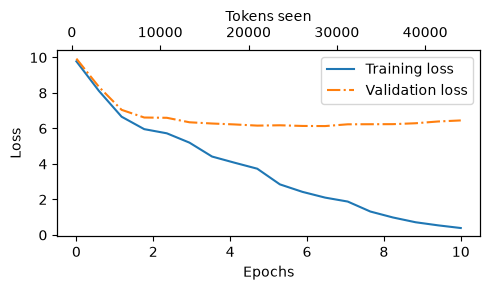

In [36]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = ax1.twiny()                       # second x-axis sharing the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)   # invisible, only to align the ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()
    plt.show()


epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## 17. Decoding Strategies: Temperature and Top-k

Section 10 used greedy decoding - always the highest-scoring token. That is deterministic, and
with a memorizing model it reproduces training text word for word. Two adjustments make the
output vary, and both act on the logits before the softmax.

**Temperature** divides the logits by a constant. Values below 1 sharpen the distribution toward
the top token; values above 1 flatten it toward uniform; sampling then draws from the result
instead of taking the maximum.

**Top-k** keeps only the `k` highest logits and sets the rest to `-inf`, so after the softmax
they hold exactly zero probability and the remaining `k` renormalize among themselves.

**Design decisions**

- **Scaling logits rather than probabilities.** Dividing probabilities would not produce a valid
  distribution without renormalizing, and the result would not match what temperature is defined
  to mean. Scaling before the softmax keeps the output normalized by construction.
- **Masking with `-inf` rather than deleting entries.** The tensor keeps its full vocabulary
  width, so token IDs remain valid indices, and `exp(-inf) = 0` makes the softmax do the
  renormalization for free.
- **Top-k applied before temperature.** Because masking happens in logit space and temperature is
  a positive scaling, the surviving set is the same either way - but filtering first means `k`
  always refers to the model's own ranking, independent of the temperature setting.
- **`temperature=0.0` as the default.** It selects the `argmax` branch, so the new `generate`
  function reduces exactly to `generate_text_simple` unless sampling is asked for. Note that
  dividing by a temperature of 0 would be undefined, which is why it is a branch rather than a
  divisor.
- **`eos_id` early stopping** ends generation at the end-of-text token instead of always emitting
  `max_new_tokens`. It is optional because a model trained on one continuous story rarely emits
  that token.
- **Top-k, not nucleus (top-p) sampling.** Top-k takes a fixed count regardless of how confident
  the model is; top-p takes as many tokens as needed to reach a cumulative probability mass, so
  it adapts. Top-k is one `topk` call and one `where`, which is why it appears here first.

In [37]:
model.to("cpu")   # inference on a model this size does not need a GPU
model.eval()

# Greedy decoding for comparison: the trained model now reproduces its training text.
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"],
)
print("Greedy output:\n", token_ids_to_text(token_ids, tokenizer))

Greedy output:
 Every effort moves you know," was one of the axioms he laid down across the Sevres and silver of an exquisitely appointed lun


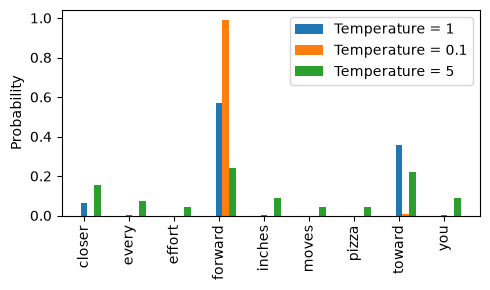

In [38]:
# A 9-word vocabulary makes the effect of temperature visible in one plot.
vocab = {"closer": 0, "every": 1, "effort": 2, "forward": 3, "inches": 4,
         "moves": 5, "pizza": 6, "toward": 7, "you": 8}
inverse_vocab = {v: k for k, v in vocab.items()}

next_token_logits = torch.tensor([4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79])


def softmax_with_temperature(logits, temperature):
    return torch.softmax(logits / temperature, dim=0)


temperatures = [1, 0.1, 5]     # unchanged, sharper, flatter
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f"Temperature = {T}")
ax.set_ylabel("Probability")
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

In [39]:
# Sampling instead of argmax: "forward" still wins most draws, but not every draw.
probas = torch.softmax(next_token_logits, dim=0)
torch.manual_seed(123)
sample = [torch.multinomial(probas, num_samples=1).item() for _ in range(1_000)]
for i, freq in enumerate(torch.bincount(torch.tensor(sample))):
    print(f"{freq:>4} x {inverse_vocab[i]}")

  73 x closer
   0 x every
   0 x effort
 582 x forward
   2 x inches
   0 x moves
   0 x pizza
 343 x toward


In [40]:
# Top-k: keep the 3 highest logits, send the rest to -inf, then softmax.
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits   :", top_logits)
print("Top positions:", top_pos)

new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")),
    other=next_token_logits,
)
print("Masked logits:", new_logits)
print("Probabilities:", torch.softmax(new_logits, dim=0))

Top logits   : tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])
Masked logits: tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])
Probabilities: tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [41]:
def generate(model, idx, max_new_tokens, context_size,
             temperature=0.0, top_k=None, eos_id=None):
    """Autoregressive generation with optional top-k filtering and temperature sampling."""
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # Keep only the top_k logits; everything else becomes -inf (zero probability).
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float("-inf")).to(logits.device),
                logits,
            )

        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)    # sample
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # greedy, as before

        if idx_next == eos_id:
            break

        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [42]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4,
)
print("Sampled output:\n", token_ids_to_text(token_ids, tokenizer))

Sampled output:
 Every effort moves you stand to work on surprise, a one of us had gone with random-


## 18. Saving and Loading Weights

A trained model is worth keeping. PyTorch saves a `state_dict` - a plain dictionary mapping
parameter names to tensors - rather than the model object itself.

**Design decisions**

- **`state_dict` rather than `torch.save(model)`.** Saving the object pickles a reference to the
  class, so the file only loads if `GPTModel` is importable from the same module path with a
  compatible definition. A `state_dict` is just tensors; reconstruct the architecture in code,
  then pour the weights in. This is also what makes loading OpenAI's published GPT-2 weights into
  this class possible.
- **Saving the optimizer state too, when training will resume.** AdamW keeps two running
  averages per parameter. Restoring only the weights resets those to zero, and the first steps
  after resuming take badly scaled updates until the averages rebuild.
- **`model.eval()` after loading for inference.** A freshly constructed module is in train mode,
  so dropout would be active and generation nondeterministic. `model.train()` is the matching
  call when resuming training.
- **The `.pth` extension is convention only** - `torch.save` writes a zip archive regardless of
  the name.

In [43]:
# Weights only.
torch.save(model.state_dict(), "model.pth")

reloaded = GPTModel(GPT_CONFIG_124M)
reloaded.load_state_dict(torch.load("model.pth"))
reloaded.eval()
print("Weights reloaded into a fresh model.")

Weights reloaded into a fresh model.


In [44]:
# Weights plus optimizer state, for resuming training later.
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer.pth",
)

checkpoint = torch.load("model_and_optimizer.pth")
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train()
print("Model and optimizer restored; training could continue from here.")

Model and optimizer restored; training could continue from here.


## Summary

A complete GPT-2 (124M) model, built and trained in the order it executes:

**Architecture (1-10).**

- **LayerNorm**, **GELU**, and **FeedForward** - each defined once, each explicit rather than
  delegated to a PyTorch builtin, so the arithmetic is visible.
- **Multi-head causal self-attention** with the causal mask held as a registered buffer and
  scores scaled by `sqrt(head_dim)`.
- A **pre-LayerNorm Transformer block** whose residual path runs unbroken from input to
  output.
- The assembled **GPTModel**: learned token and positional embeddings added together, twelve
  blocks, a final norm required by the pre-LN placement, and a bias-free output head kept
  separate from the token embedding - GPT-2 ties the two, which is the 38.6M difference
  between the count here and the 124M label.
- **Greedy generation**, demonstrating the forward pass end to end on random weights.

**Training and inference (11-18).**

- **Cross-entropy loss** over next-token targets, with **perplexity** as its interpretable
  form. An untrained model sits at `ln(50257) = 10.82`, which is the baseline every run is
  measured against.
- A **sliding-window Dataset** producing input/target pairs shifted by one position, split
  90/10 into training and validation loaders.
- A **training loop** using AdamW, evaluating both splits periodically and printing a sample
  after each epoch. On 4600 training tokens the model memorizes the corpus, and the diverging
  loss curves show exactly that.
- **Temperature scaling and top-k sampling**, both acting on the logits before the softmax,
  combined into one `generate` function that reduces to greedy decoding at `temperature=0`.
- **Checkpointing** via `state_dict`, with the optimizer state saved alongside when training
  is to be resumed.

The choices that would most change this model if reversed: pre-LN vs post-LN (trainability at
depth), learned vs rotary positional embeddings (whether context length can be extended),
tied vs untied embeddings (38.6M parameters against convergence speed), and corpus size (which is the only reason
the model here memorizes rather than generalizes).

The next step is **scale, or a pretrained checkpoint**: the same architecture loading OpenAI's
published GPT-2 weights, after which the generated text is coherent without any training run
of your own.
